# Multi-layer inverse design of a vertical grating coupler

Jointly optimize two independent silicon patterns in a **full-vector 3D Beamz simulation** to couple a TE waveguide mode to a normally emitted Gaussian beam. Reciprocity gives the corresponding Gaussian-to-waveguide coupling.

This example addresses [issue #240](https://github.com/beamzorg/beamz/issues/240) and builds on [PR #233](https://github.com/beamzorg/beamz/pull/233). It follows the two-layer design idea of [Hammond et al., Optics Express 30, 31058–31072 (2022)](https://doi.org/10.1364/OE.466015) ([open PDF](https://par.nsf.gov/servlets/purl/10416505)). [Meep PR #3295](https://github.com/NanoComp/meep/pull/3295) is a related, later example with a single patterned layer and a movable metal reflector; it is not the same device.

**Scope.** This is a reproducible single-polarization demonstration, not a numerical reproduction of the paper's foundry device. The paper uses a 10 × 10 µm aperture, two foundry layers, an epigraph minimax optimizer, and fabrication constraints. Here we use a smaller open stack, a smooth worst-wavelength log objective, Adam, and layer-specific conic filters. Filtering and binarization alone do **not** establish foundry DRC compliance. No measured or published efficiency is used as a simulated result.

## Setup

Install Beamz from this branch with a CUDA-enabled JAX installation and notebook dependencies. The saved run uses an **RTX 3090**. The default 50 nm mesh is deliberately small enough for local differentiation; the final section tests runtime and mesh sensitivity.

Run all cells, or run the same implementation from the repository root:
```bash
XLA_PYTHON_CLIENT_PREALLOCATE=false python -m examples.optimization.multilayer_grating --output results/multilayer_grating_50nm
python -m examples.optimization.multilayer_grating --validate --output results/multilayer_grating_50nm
```
`--smoke` selects a 100 nm mesh and two updates. Raw artifacts go into the ignored `results/` directory. The notebook retains its plots and numerical outputs.

In [1]:
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import hashlib
import json
import sys
from dataclasses import asdict, replace
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "beamz" / "__init__.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from examples.optimization.multilayer_grating import Config, GratingProblem, optimize, validate_design

print("JAX:", jax.__version__)
print("Devices:", [(str(d), d.device_kind) for d in jax.devices()])
if jax.default_backend() != "gpu":
    raise RuntimeError("Select a CUDA-enabled JAX kernel for this 3D optimization.")

config = Config()
OUTPUT = ROOT / "results" / "multilayer_grating_50nm"
FORCE_RUN = False
print(json.dumps(asdict(config), indent=2))

JAX: 0.9.0


Devices: [('cuda:0', 'NVIDIA GeForce RTX 3090')]
{
  "dx": 0.05,
  "aperture": 3.2,
  "waist": 1.5,
  "si_thickness": 0.22,
  "oxide_gap": 0.1,
  "poly_thickness": 0.16,
  "box_thickness": 2.0,
  "pml": 0.6,
  "run_time_fs": 220.0,
  "chunk_steps": 32,
  "wavelengths": [
    1.54,
    1.55,
    1.56
  ],
  "filter_radii": [
    0.2,
    0.1
  ],
  "learning_rate": 0.025,
  "steps_per_beta": 16,
  "betas": [
    2.0,
    4.0,
    8.0
  ],
  "seed": 240
}


## Open stack and design variables

The demonstration uses 220 nm silicon, a 100 nm oxide spacer, and 160 nm upper silicon, in homogeneous SiO₂ cladding with a silicon handle beneath the BOX. These are **example parameters**, not undisclosed 45CLO process values. Both silicon layers use n = 3.48 and oxide n = 1.44 over this narrow wavelength band. There is no aluminum mirror, ARC, or dual-polarization port.

Each layer owns a 2D density, extruded through its thickness. The lower layer connects directly to a 500 nm waveguide. The densities are symmetric about the waveguide axis but independent of each other. Separate 200 nm and 100 nm conic-filter radii precede tanh projection. Beta continuation sharpens the patterns gradually. Native Beamz rasterization provides the layer fill fractions on each staggered Yee support.

The target is a y-polarized, upward paraxial Gaussian in oxide with its waist at the monitor plane. Its quoted waist is the **1/e electric-field radius**; the intensity mode-field diameter is twice this value. It is normalized over the infinite plane, so truncating the monitor never artificially renormalizes the captured power.

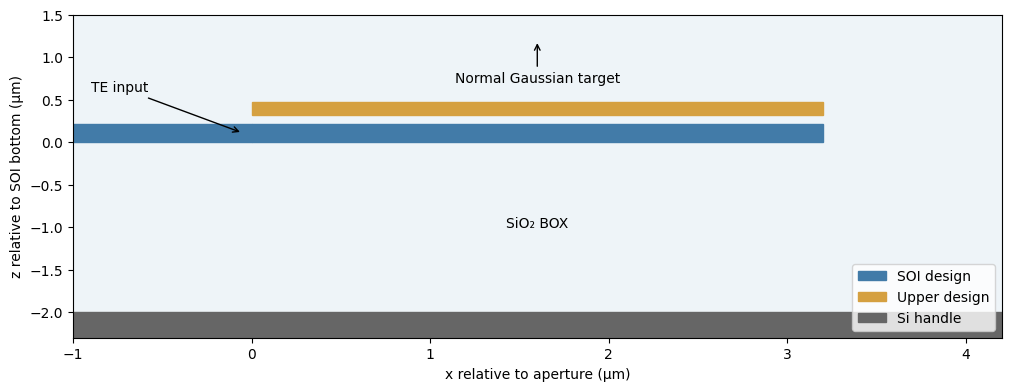

In [2]:
fig, ax = plt.subplots(figsize=(10, 3.8), layout="constrained")
levels = [(0, config.si_thickness, "SOI design", "#427ba8"),
          (config.si_thickness + config.oxide_gap, config.poly_thickness, "Upper design", "#d5a040")]
ax.set_facecolor("#eef4f8")
for z, thickness, name, color in levels:
    ax.add_patch(Rectangle((0, z), config.aperture, thickness, color=color, label=name))
ax.add_patch(Rectangle((-1, 0), 1, config.si_thickness, color="#427ba8"))
ax.add_patch(Rectangle((-1, -config.box_thickness-0.3), config.aperture+2, 0.3, color="0.4", label="Si handle"))
ax.annotate("TE input", xy=(-0.05, config.si_thickness / 2), xytext=(-0.9, 0.6), arrowprops={"arrowstyle": "->"})
ax.annotate("Normal Gaussian target", xy=(config.aperture/2, 1.2), xytext=(config.aperture/2, 0.7), ha="center", arrowprops={"arrowstyle": "->"})
ax.text(config.aperture/2, -config.box_thickness/2, "SiO₂ BOX", ha="center")
ax.set(xlim=(-1, config.aperture+1), ylim=(-config.box_thickness-0.3, 1.5), xlabel="x relative to aperture (µm)", ylabel="z relative to SOI bottom (µm)")
ax.legend(loc="lower right")
plt.show()

## Objective and discrete adjoint

Launch the fundamental TE waveguide mode and use a separate straight-waveguide simulation to measure its incident spectrum, $P_\mathrm{in}(\lambda)$. The source requests four eigensolver candidates near effective index 2.5; the 2 µm BOX keeps the silicon handle outside the padded mode plane. Calibration verifies TE polarization and even transverse electric-field symmetry before accepting the reference. That calibration stays fixed throughout optimization; reflected fields cannot improve the objective by changing its denominator.

At the upper monitor, compute the Lorentz overlap with a unit-power Gaussian:

$$a = \frac14\int [\mathbf E\times\mathbf H_g^*+\mathbf E_g^*\times\mathbf H]\cdot\hat z\,dA,\qquad \eta=|a|^2/P_\mathrm{in}.$$

Spatial colocation and the half-timestep magnetic-field phase correction follow Beamz's monitor convention. Both electric and magnetic fields are used to separate propagation directions. Optimize

$$L=\tau\log\sum_{\lambda\in\{1540,1550,1560\}\,\mathrm{nm}}\exp[-\log(\max(\eta_\lambda,10^{-12}))/\tau],\qquad\tau=0.1.$$

JAX differentiates the actual discrete Beamz time-stepping program, including the filter and projection. Checkpointing recomputes timestep chunks during the backward pass to reduce memory. The helper uses the compiled-program interface because the high-level result objects are detached NumPy data. Before updating a design, central differences check the full electromagnetic gradient separately in both layers.

In [3]:
# A result is reusable only for this configuration and implementation.
implementation = ROOT / "examples" / "optimization" / "multilayer_grating.py"
fingerprint = hashlib.sha256(implementation.read_bytes()).hexdigest()
report_path = OUTPUT / "report.json"
report = json.loads(report_path.read_text()) if report_path.exists() else {}
same_config = json.dumps(report.get("config"), sort_keys=True) == json.dumps(asdict(config), sort_keys=True)
if FORCE_RUN or not same_config or report.get("implementation_sha256") != fingerprint:
    problem = GratingProblem(config)
    density, history, report = optimize(problem, OUTPUT)
    del problem
    jax.clear_caches()
else:
    print("Reusing matching local run:", OUTPUT)
with np.load(OUTPUT / "history.npz") as saved:
    history = saved["history"]
    designs = saved["designs"]
with np.load(OUTPUT / "final.npz") as saved:
    density, physical, efficiency = saved["density"], saved["physical"], saved["efficiency"]
print("Device:", report["device_kind"])
print("Input-mode checks:", report["input_mode"])
print("Grid:", report["grid"], "timesteps:", report["steps"])
for check in report["gradient_checks"]:
    print(f"Layer {check['layer']}: autodiff={check['autodiff']:.6g}, FD={check['finite_difference']:.6g}, relative error={check['relative_error']:.3%}")
print("Initial efficiencies:", report["initial_efficiency"])
print("Final efficiencies:", report["final_efficiency"])
print("Worst-wavelength improvement:", min(report["final_efficiency"]) / min(report["initial_efficiency"]))

Reusing matching local run: /home/quentinwach/beamz/beamz-issue240/results/multilayer_grating_50nm
Device: NVIDIA GeForce RTX 3090
Input-mode checks: {'te_fraction': 0.9855560064315796, 'ey_symmetry_error': 0.0}
Grid: [128, 104, 102] timesteps: 2857
Layer 0: autodiff=2.26643, FD=2.26641, relative error=0.001%
Layer 1: autodiff=5.97142, FD=5.972, relative error=0.010%
Initial efficiencies: [0.00023859656357672065, 0.00022703206923324615, 0.00023523028357885778]
Final efficiencies: [0.6630672812461853, 0.6798487901687622, 0.6731224656105042]
Worst-wavelength improvement: 2920.588635277641


## Optimization history and independent layer patterns

The curve records the design **before** each update. The final marker is a fresh evaluation after the last update. Projection changes can cause jumps at epoch boundaries; no monotonicity is assumed across beta changes.

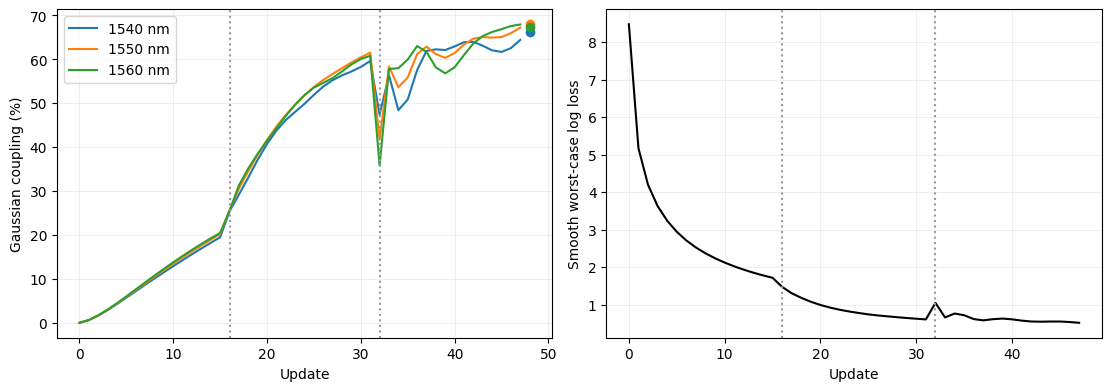

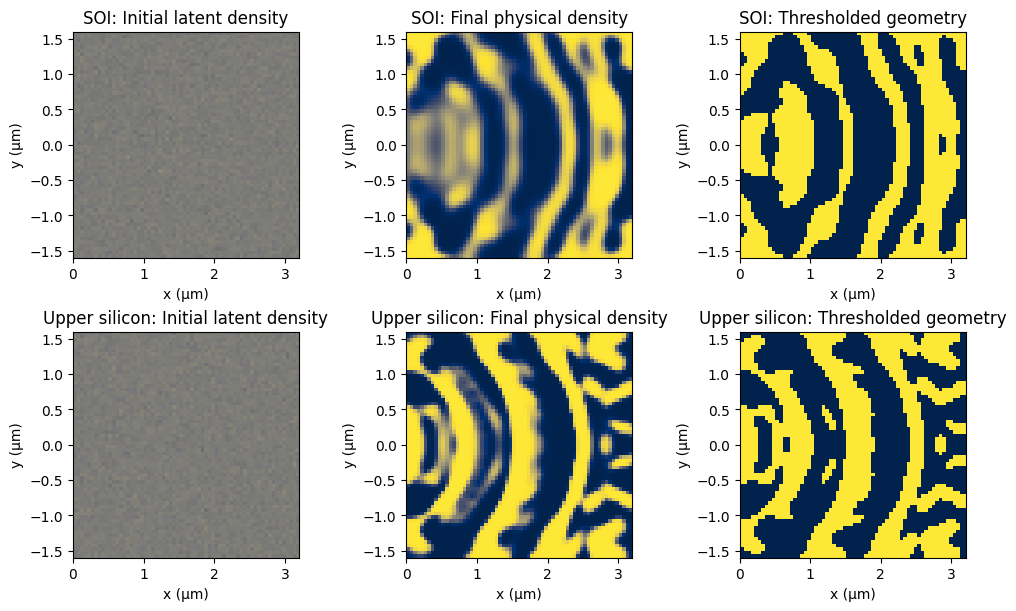

Intermediate-material fraction by layer: [0.47705078 0.26513672]


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout="constrained")
for i, wavelength in enumerate(config.wavelengths):
    axes[0].plot(np.arange(len(history)), 100 * history[:, i+2], label=f"{wavelength*1000:.0f} nm")
    axes[0].plot(len(history), 100*efficiency[i], "o", color=f"C{i}")
axes[0].set(xlabel="Update", ylabel="Gaussian coupling (%)")
axes[0].legend()
axes[1].plot(history[:, 1], color="black")
axes[1].set(xlabel="Update", ylabel="Smooth worst-case log loss")
for ax in axes:
    for boundary in range(config.steps_per_beta, len(history), config.steps_per_beta):
        ax.axvline(boundary, color="0.6", ls=":")
    ax.grid(alpha=0.2)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(10, 6), layout="constrained")
for layer, name in enumerate(("SOI", "Upper silicon")):
    for col, (values, label) in enumerate(((designs[0, layer], "Initial latent density"),
                                         (physical[layer], "Final physical density"),
                                         (physical[layer] >= 0.5, "Thresholded geometry"))):
        axes[layer, col].imshow(values, origin="lower", extent=(0, config.aperture, -config.aperture/2, config.aperture/2), cmap="cividis", vmin=0, vmax=1)
        axes[layer, col].set(title=f"{name}: {label}", xlabel="x (µm)", ylabel="y (µm)")
plt.show()
print("Intermediate-material fraction by layer:", np.mean((physical > 0.1) & (physical < 0.9), axis=(1, 2)))

## Validation: runtime, mesh, and binary geometry

The optimization mesh is not a convergence claim. Re-evaluate the final design with twice the runtime over 1500–1600 nm, then halve the cell size at the three design wavelengths. Transfer the latent density to the finer mesh and retain the physical filter radii. Also evaluate a separately thresholded binary geometry: its curve is not the relaxed design's curve.

A large difference is evidence that more refinement or optimization is needed. The small aperture and short optimization budget are intended to demonstrate the workflow, not match the paper's efficiency. The larger-aperture configuration below requires a separate memory and convergence study.

{
  "wavelengths": [
    1.54,
    1.55,
    1.56
  ],
  "long_time_efficiency": [
    0.6625496745109558,
    0.6799113750457764,
    0.6736623644828796
  ],
  "fine_mesh_efficiency": [
    0.6648644208908081,
    0.6664424538612366,
    0.6459134221076965
  ],
  "fine_dx_um": 0.025,
  "run_time_fs": 440.0
}
Relative runtime change: [-7.80624757e-04  9.20570543e-05  8.02081196e-04]
Relative mesh change: [ 0.00349369 -0.01980982 -0.04119117]
Relaxed design, optimization mesh (%): [66.306725 67.98488  67.31225 ]
Relaxed design, finer mesh (%): [66.48644209 66.64424539 64.59134221]
Thresholded binary design, optimization mesh (%): [49.9972254  47.79697359 43.73703301]
These are distinct numerical models of the open demonstration stack, not a foundry-device reproduction.


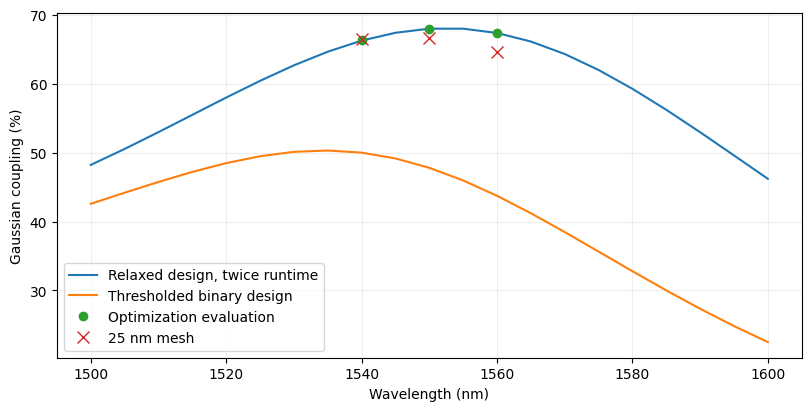

In [5]:
validation_path = OUTPUT / "validation.json"
# Validation is linked to the exact final density, not just the output directory.
validation_key = hashlib.sha256(density.tobytes() + fingerprint.encode()).hexdigest()
key_path = OUTPUT / "validation-key.txt"
if FORCE_RUN or not validation_path.exists() or not key_path.exists() or key_path.read_text() != validation_key:
    validation = validate_design(config, density, OUTPUT)
    key_path.write_text(validation_key)
else:
    validation = json.loads(validation_path.read_text())
with np.load(OUTPUT / "spectrum.npz") as saved:
    spectrum = dict(saved)
print(json.dumps(validation, indent=2))
long_time = np.array(validation["long_time_efficiency"])
fine = np.array(validation["fine_mesh_efficiency"])
print("Relative runtime change:", (long_time - efficiency) / efficiency)
print("Relative mesh change:", (fine - long_time) / long_time)
binary_at_design = np.interp(config.wavelengths, spectrum["wavelengths"], spectrum["binary_efficiency"])
print("Relaxed design, optimization mesh (%):", 100*efficiency)
print("Relaxed design, finer mesh (%):", 100*fine)
print("Thresholded binary design, optimization mesh (%):", 100*binary_at_design)
print("These are distinct numerical models of the open demonstration stack, not a foundry-device reproduction.")

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.plot(1000*spectrum["wavelengths"], 100*spectrum["efficiency"], label="Relaxed design, twice runtime")
ax.plot(1000*spectrum["wavelengths"], 100*spectrum["binary_efficiency"], label="Thresholded binary design")
ax.plot(1000*np.array(config.wavelengths), 100*efficiency, "o", label="Optimization evaluation")
ax.plot(1000*np.array(config.wavelengths), 100*fine, "x", ms=8, label=f"{validation['fine_dx_um']*1000:g} nm mesh")
ax.set(xlabel="Wavelength (nm)", ylabel="Gaussian coupling (%)")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

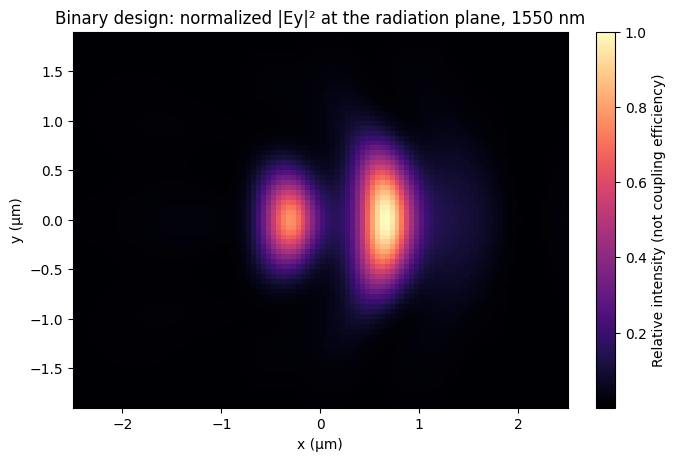

In [6]:
index = np.argmin(abs(spectrum["wavelengths"] - 1.55))
x, y = spectrum["fiber_x_um"], spectrum["fiber_y_um"]
field = spectrum["fiber_fields"][1, index].reshape(len(y), len(x))
fig, ax = plt.subplots(figsize=(7, 4.5), layout="constrained")
image = ax.pcolormesh(x, y, abs(field)**2 / max(float(np.max(abs(field)**2)), 1e-30), shading="auto", cmap="magma")
ax.set(title="Binary design: normalized |Ey|² at the radiation plane, 1550 nm", xlabel="x (µm)", ylabel="y (µm)", aspect="equal")
fig.colorbar(image, ax=ax, label="Relative intensity (not coupling efficiency)")
plt.show()

## Extending the experiment

To explore a paper-sized aperture, start from `replace(config, aperture=10.0, waist=5.2, box_thickness=2.0, run_time_fs=600.0)` in a **new output directory**. This only changes the scale of the open demonstration; it does not reproduce the foundry stack. Estimate memory before differentiating that larger domain. Tune `chunk_steps` to balance stored chunk boundaries against recomputation memory, or reduce aperture if the GPU cannot hold the checkpoint states.

For a quantitative device study, continue mesh and runtime refinement, enlarge the PML and monitor aperture, refine the paraxial target or model the actual fiber/BEOL stack, and implement explicit fabrication constraints before claiming manufacturability. A dual-polarization extension needs a second waveguide and independently verified orthogonal-mode objectives. The outputs above make no claims about those cases.

The example saves every evaluated latent density, the next density, final physical densities, spectra, calibration power, configuration, GPU identity, and gradient-check evidence. The history files do not include Adam moments and therefore are analysis artifacts, not exact optimizer-resume checkpoints.